In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("extended_dataset.csv")
df.columns

C:\Users\themi\AppData\Local\Temp\ipykernel_20368\3117683285.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("extended_dataset.csv")


Index(['appid', 'name', 'type', 'is_free', 'release_date', 'required_age',
       'short_description', 'supported_languages', 'header_image',
       'background', 'metacritic_score', 'recommendations_total',
       'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux',
       'mat_initial_price', 'mat_final_price', 'mat_discount_percent',
       'mat_currency', 'mat_achievement_count', 'mat_pc_os_min',
       'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min',
       'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec',
       'mat_pc_graphics_rec', 'created_at', 'updated_at', 'min_storage',
       'rec_storage'],
      dtype='object')

In [9]:
# Print a few sample rows with the selected columns
print(df[['appid', 'name', 'min_storage', 'rec_storage', 'release_date']].head())

# Or get a random sample
print(df[['appid', 'name', 'min_storage', 'rec_storage', 'release_date']].sample(5, random_state=1))

   appid                       name  min_storage  rec_storage release_date
0     10             Counter-Strike          NaN          NaN   2000-11-01
1     20      Team Fortress Classic          NaN          NaN   1999-04-01
2     30              Day of Defeat          NaN          NaN   2003-05-01
3     40         Deathmatch Classic          NaN          NaN   2001-06-01
4     50  Half-Life: Opposing Force          NaN          NaN   1999-11-01
          appid                                    name  min_storage  \
106536  3460570                              Deck Combo         0.25   
50497   1618450             Anatidae: To The Nest Level         0.02   
112387  3764520                     Little Town Secrets         3.07   
44942   1466860  Age of Empires IV: Anniversary Edition        50.00   
94709   3004710                          NO MORE HUMANS         3.00   

        rec_storage release_date  
106536          NaN   2025-02-27  
50497           NaN   2021-05-25  
112387      

In [4]:
# Find all rows where min_storage is NaN
missing_min_storage = df[df['min_storage'].isnull()]

# Show selected columns
print(missing_min_storage[['appid', 'name', 'min_storage', 'rec_storage']])

# Optional: count how many
print(f"Rows with missing min_storage: {len(missing_min_storage)}")

          appid                              name  min_storage  rec_storage
0            10                    Counter-Strike          NaN          NaN
1            20             Team Fortress Classic          NaN          NaN
2            30                     Day of Defeat          NaN          NaN
3            40                Deathmatch Classic          NaN          NaN
4            50         Half-Life: Opposing Force          NaN          NaN
...         ...                               ...          ...          ...
115291  3987850      Magician Impossible Playtest          NaN          NaN
115292  3989830                  Barfbot Playtest          NaN          NaN
115293  3989870              The Mariner Playtest          NaN          NaN
115294  3990400    Big BEAUTIFUL Van Derby Racing          NaN          NaN
115295  3990870  Replace the Lamp: The Last Shift          NaN          NaN

[15698 rows x 4 columns]
Rows with missing min_storage: 15698


In [ ]:
print(
    df[['appid', 'name', 'min_storage']]
    .sort_values('min_storage', ascending=False)
    .head(20)
)

          appid                                         name  min_storage
101577  3261190                                 Besert Bydra  1000000.000
92769   2934320                                Where are We?   323333.123
10492    512460            Nature And Life - Drunk On Nectar    10000.000
108881  3575880                        Fernandez Big Mystery     6500.000
83870   2628950                                  Paramorfosi     5000.000
90079   2842120                              Midnight Cruise     5000.000
104569  3381380                                   Starry Sky     4096.000
22894    853050                   El Hijo - A Wild West Tale     3500.000
28615   1015090                             Last Day of Rome     2200.000
53725   1709210  Love Duction! The Guide for Galactic Lovers     2200.000
85630   2688610                             Forgotten Knight     2048.000
96287   3061590                             Sunset afterglow     2000.000
55203   1750240                       

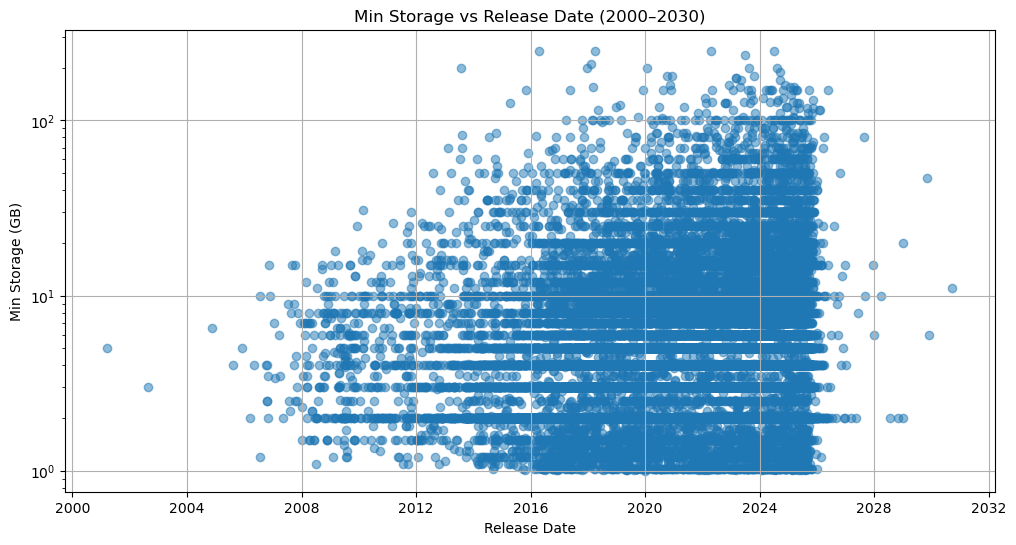

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only rows with:
# - non-null min_storage
# - min_storage > 1
# - min_storage <= 500 GB
df_filtered = df[
    df['min_storage'].notnull() &
    (df['min_storage'] > 1) &
    (df['min_storage'] <= 250)
].copy()

# Convert release_date to datetime
df_filtered['release_date'] = pd.to_datetime(
    df_filtered['release_date'],
    errors='coerce'
)

# Keep only dates between 2000 and 2030
df_filtered = df_filtered[
    (df_filtered['release_date'].dt.year >= 2000) &
    (df_filtered['release_date'].dt.year <= 2030)
]

# Plot
plt.figure(figsize=(12, 6))

plt.scatter(
    df_filtered['release_date'],
    df_filtered['min_storage'],
    alpha=0.5
)

plt.yscale('log')

plt.xlabel('Release Date')
plt.ylabel('Min Storage (GB)')
plt.title('Min Storage vs Release Date (2000–2030)')
plt.grid(True)

plt.show()

In [22]:
# Show the games with the highest min_storage
top_storage_games = (
    df_filtered[['appid', 'name', 'min_storage', 'release_date']]
    .sort_values('min_storage', ascending=False)
    .head(20)
)

print(top_storage_games)

         appid                                  name  min_storage release_date
96118  3055630                     Retro Pistol Hero        250.0   2024-07-07
20092   777180                   Game Server Toolbox        250.0   2018-03-30
8128    439730                            XO-Planets        250.0   2016-04-21
62148  1944940                 Easter Eggstravaganza        250.0   2022-04-15
78193  2438490                         FireRun - 逃生門        237.0   2023-06-30
16356   678460                               Tekling        210.0   2018-02-05
19422   759650                    Christmas Puzzle 3        200.0   2017-12-15
80992  2529510                   Fish on the desktop        200.0   2023-08-18
1570    223750               DCS World Steam Edition        200.0   2013-08-02
36676  1228680                           Goblet Cave        200.0   2020-01-27
81493  2545650                DOOM Eternal: idStudio        200.0   2024-08-08
74286  2322010                   God of War Ragnarök

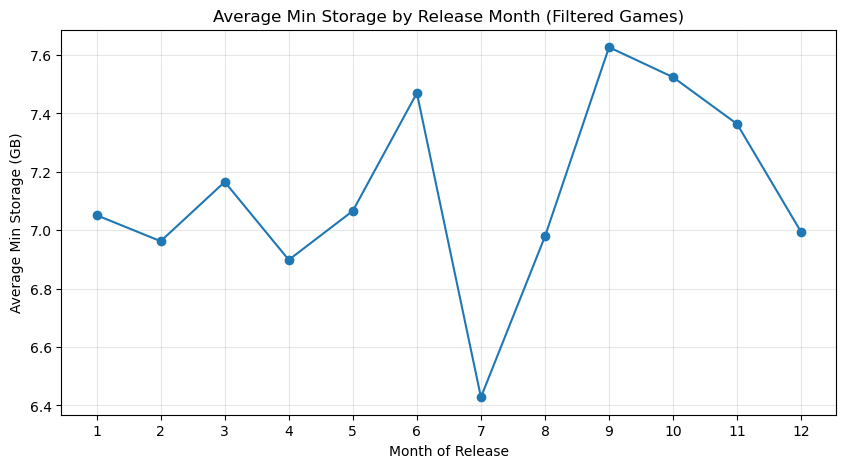

In [23]:
# Ensure datetime
df_filtered['release_date'] = pd.to_datetime(df_filtered['release_date'], errors='coerce')

# Keep valid dates
df_plot = df_filtered[
    df_filtered['release_date'].notnull() &
    (df_filtered['release_date'].dt.year >= 2000) &
    (df_filtered['release_date'].dt.year <= 2030)
].copy()

# Extract month (1–12)
df_plot['month'] = df_plot['release_date'].dt.month

# Compute average min_storage per month
monthly_avg = df_plot.groupby('month')['min_storage'].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.xticks(range(1, 13))
plt.xlabel('Month of Release')
plt.ylabel('Average Min Storage (GB)')
plt.title('Average Min Storage by Release Month (Filtered Games)')
plt.grid(True, alpha=0.3)

plt.show()

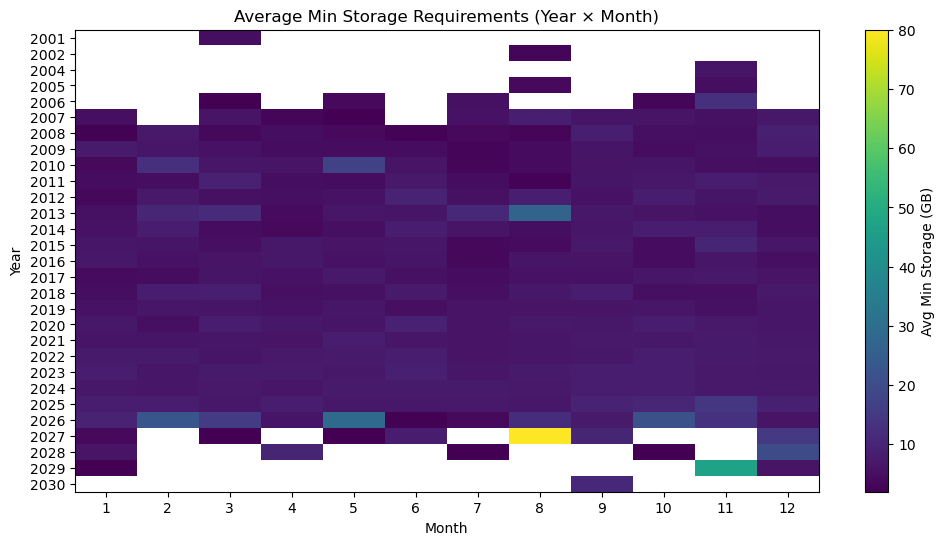

In [24]:
# Ensure datetime
df_plot = df_filtered.copy()
df_plot['release_date'] = pd.to_datetime(df_plot['release_date'], errors='coerce')

# Keep valid dates
df_plot = df_plot[
    df_plot['release_date'].notnull() &
    (df_plot['release_date'].dt.year >= 2000) &
    (df_plot['release_date'].dt.year <= 2030)
].copy()

# Extract year and month
df_plot['year'] = df_plot['release_date'].dt.year
df_plot['month'] = df_plot['release_date'].dt.month

# Average min_storage per (year, month)
pivot = df_plot.pivot_table(
    index='year',
    columns='month',
    values='min_storage',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(12, 6))
plt.imshow(pivot, aspect='auto', cmap='viridis')

plt.colorbar(label='Avg Min Storage (GB)')

plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(12), range(1, 13))

plt.xlabel('Month')
plt.ylabel('Year')
plt.title('Average Min Storage Requirements (Year × Month)')

plt.show()

In [26]:
# Ensure datetime
df_2027 = df_filtered.copy()
df_2027['release_date'] = pd.to_datetime(df_2027['release_date'], errors='coerce')

# Filter games released in 2027
df_2027 = df_2027[
    df_2027['release_date'].notnull() &
    (df_2027['release_date'].dt.year == 2027)
]

# Print relevant columns
print(df_2027[['appid', 'name', 'release_date', 'min_storage', 'rec_storage']]
      .sort_values('release_date'))

          appid                            name release_date  min_storage  \
95173   3021700                     Astrostrike   2027-01-04          4.0   
107703  3515660               Just a simulation   2027-03-15          2.0   
72976   2281890  Primitive Environment Survival   2027-05-13          2.0   
69103   2170690               ShotFightDisaster   2027-06-11          8.0   
67669   2126960                      PANDECROWN   2027-08-21         80.0   
110853  3675880                Proximity Effect   2027-09-01         10.0   
107956  3529930                The Great Tribes   2027-12-15         15.0   

        rec_storage  
95173           6.0  
107703          NaN  
72976           NaN  
69103           NaN  
67669          80.0  
110853          NaN  
107956         15.0  


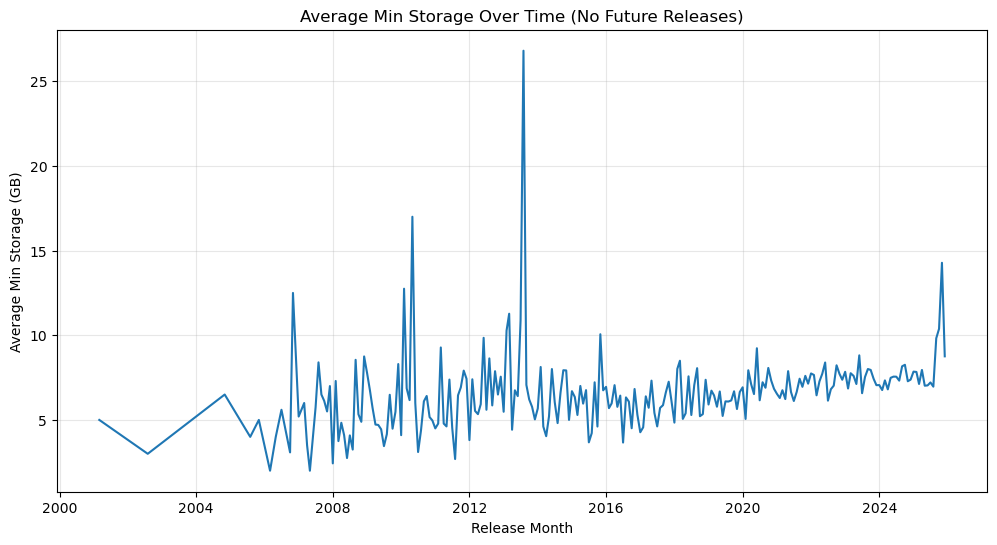

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_filtered.copy()

# Ensure datetime
df_plot['release_date'] = pd.to_datetime(df_plot['release_date'], errors='coerce')

# Filter:
# - valid dates
# - within 2000–2030
# - not in the future (past current day)
today = pd.Timestamp.today()

df_plot = df_plot[
    df_plot['release_date'].notnull() &
    (df_plot['release_date'].dt.year >= 2000) &
    (df_plot['release_date'].dt.year <= 2025)
].copy()

# Create year-month bucket
df_plot['year_month'] = df_plot['release_date'].dt.to_period('M')

# Compute monthly average
monthly_avg = (
    df_plot.groupby('year_month')['min_storage']
    .mean()
    .sort_index()
)

# Convert for plotting
monthly_avg.index = monthly_avg.index.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values)

plt.xlabel('Release Month')
plt.ylabel('Average Min Storage (GB)')
plt.title('Average Min Storage Over Time (No Future Releases)')
plt.grid(True, alpha=0.3)

plt.show()